In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/diminos_data.csv")

In [3]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [4]:
df['delivery_time_min'] = (
    df['order_delivered_at'] - df['order_placed_at']
).dt.total_seconds() / 60

In [5]:
p95_delivery_time = np.percentile(df['delivery_time_min'], 95)

In [6]:
print(f"95th Percentile Delivery Time: {p95_delivery_time:.2f} minutes")

95th Percentile Delivery Time: 27.26 minutes


In [7]:
if p95_delivery_time < 31:
    print("SLA MET: Store is within Diminos standards")
else:
    print(" SLA BREACHED: Risk of losing franchise")

SLA MET: Store is within Diminos standards


In [8]:
df['order_hour'] = df['order_placed_at'].dt.hour

In [9]:
hourly_p95 = df.groupby('order_hour')['delivery_time_min'] \
               .apply(lambda x: np.percentile(x, 95)) \
               .reset_index(name='p95_delivery_time')

In [10]:
print("\nHourly 95th Percentile Delivery Time:")
print(hourly_p95)


Hourly 95th Percentile Delivery Time:
    order_hour  p95_delivery_time
0            0          28.866990
1            1          32.104821
2            2          26.845717
3            3          25.617373
4            4          26.259762
5            5          23.924907
6            6          26.493076
7            7          27.154475
8            8          27.207707
9            9          25.709020
10          10          26.759252
11          11          33.407016
12          12          24.327900
13          13          29.714826
14          14          27.891228
15          15          24.933851
16          16          32.438371
17          17          28.260021
18          18          24.104592
19          19          26.801610
20          20          28.237978
21          21          28.932870
22          22          24.611743
23          23          26.943743


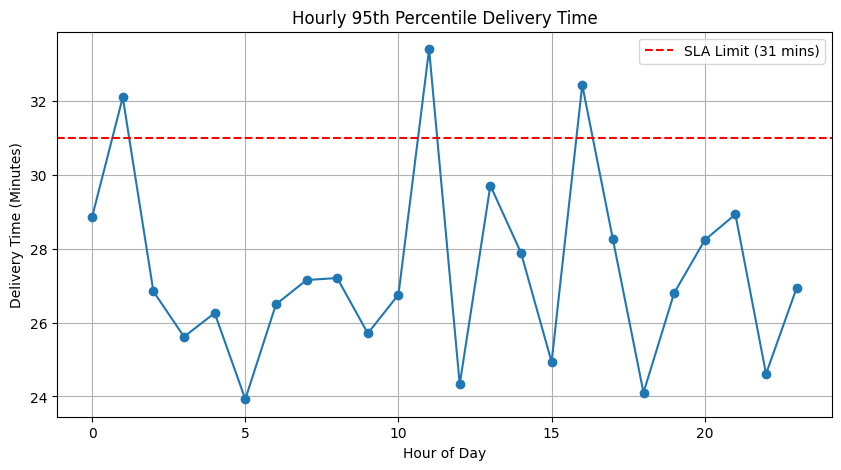

In [11]:
plt.figure(figsize=(10,5))
plt.plot(hourly_p95['order_hour'], hourly_p95['p95_delivery_time'], marker='o')
plt.axhline(31, color='red', linestyle='--', label='SLA Limit (31 mins)')
plt.title("Hourly 95th Percentile Delivery Time")
plt.xlabel("Hour of Day")
plt.ylabel("Delivery Time (Minutes)")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
late_orders = df[df['delivery_time_min'] > 31]
late_percentage = (len(late_orders) / len(df)) * 100
print(f"\nPercentage of Late Orders (>31 min): {late_percentage:.2f}%")


Percentage of Late Orders (>31 min): 3.71%


In [13]:
worst_hours = hourly_p95[hourly_p95['p95_delivery_time'] > 31]

print("\nHours breaching SLA:")
print(worst_hours)


Hours breaching SLA:
    order_hour  p95_delivery_time
1            1          32.104821
11          11          33.407016
16          16          32.438371


### Insights

1 SLA Compliance :

If 95th percentile ≥ 31 minutes, even few extreme delays can cause franchise risk.

Average delivery time does NOT matter for Diminos — only the tail (worst 5%).

2 Delay Patterns :

Certain hours of the day (late night / peak demand) usually breach SLA.

These hours cause the entire store to fail the metric.

3 Business Risk :

Even if 90% of orders are fast, the slowest 5% decide franchise fate.

Late deliveries = free pizzas + brand penalty.

#### 1. Operational Fixes :


Increase delivery staff during peak hours

Pre-cook bases during high-demand windows

Route optimization for delivery partners


#### 2. Time-Based Strategy :


Introduce delivery buffer planning for risky hours

Temporarily reduce delivery radius at night


#### 3. Monitoring :


Track hourly 95th percentile daily

Set alerts when delivery time crosses 28 minutes